In [ ]:
import random
import matplotlib.pyplot as plt

In [ ]:
def randomiseMonomerType(HProbabilityConst, PProbabilityConst):
  HProbability = random.random()*HProbabilityConst
  PProbability = random.random()*PProbabilityConst

  return 'H' if (HProbability > PProbability) else 'P'

In [ ]:
def calculateNeighbouringLocations(currentLocation):
  # print(currentLocation)
  currentX = currentLocation[0]
  currentY = currentLocation[1]

  return [
      (currentX+1, currentY),
      (currentX, currentY+1),
      (currentX-1, currentY),
      (currentX, currentY-1)
  ]

In [ ]:
def checkIfPossibleNextLocationIsValid(possibleNextLocation, blockedLocations):
  possibleNextX = possibleNextLocation[0]
  possibleNextY = possibleNextLocation[1]

  return (possibleNextX < blockedLocations['boundaries']['max'])\
  and (possibleNextX > blockedLocations['boundaries']['min'])\
  and (possibleNextY < blockedLocations['boundaries']['max'])\
  and (possibleNextY > blockedLocations['boundaries']['min'])\
  and (possibleNextLocation not in blockedLocations['previousLocations'])

In [ ]:
def foldProtein(HProbabilityConst, startingLocation, boundaries):
# Starting point
  PProbabilityConst = 1 - HProbabilityConst
  monomers = []

  monomers.append(randomiseMonomerType(HProbabilityConst, PProbabilityConst))

  blockedLocations = {
      "previousLocations": [startingLocation],
      "boundaries": boundaries
  }

  # Steps
  isBlocked = False

  while not isBlocked:

    # print(blockedLocations['previousLocations'])

    possibleNextLocations = calculateNeighbouringLocations(
        blockedLocations['previousLocations'][-1]
    )

    validNextLocations = []

    for possibleNextLocation in possibleNextLocations:
      if checkIfPossibleNextLocationIsValid(
          possibleNextLocation,
          blockedLocations
        ):
        validNextLocations.append(possibleNextLocation)

    if validNextLocations:
      isStepTaken = True
      monomers.append(
          randomiseMonomerType(
              HProbabilityConst,
              PProbabilityConst
          )
      )
      blockedLocations['previousLocations'].append(
          random.choice(validNextLocations)
      )
      # print('valid next locs:', validNextLocations)
    else:
      isBlocked = True

      return blockedLocations['previousLocations'], monomers


In [ ]:
def calculateEnergy(locations, monomers):
  # print(locations)
  # print(monomers)
  HIndices = [i for i, n in enumerate(monomers) if n == 'H']
  HLocations = [locations[j] for j in HIndices]
  # print(HLocations)

  f = 0

  for currentHLocationIndex in HIndices:
    HLocation = locations[currentHLocationIndex]
    # print('\ncurrent H location: ', HLocation)
    # print('current H location index: ', currentHLocationIndex)
    neighbouringLocations = calculateNeighbouringLocations(HLocation)
    for neighbouringLocation in neighbouringLocations:
      # print('neighbouring location: ', neighbouringLocation)
      if neighbouringLocation in HLocations:
        # print('neighbouring location has an H monomer')
        neighbouringLocationIndex = locations.index(neighbouringLocation)
        # print('neighbouring location index: ', neighbouringLocationIndex)
        if ((neighbouringLocationIndex - currentHLocationIndex) > 1):
          # print('Found a non-adjacent H monomer:')
          # print('current location: ', HLocation, 'neighbouring loc:', neighbouringLocation)
          f = f+1

  #print(f)
  return f


# Test

In [ ]:
# Test with a small nmber of steps
# locations, monomers = foldProtein(0.7, (0, 0), {'min': -2, 'max': 2})
# print(locations)
# print(monomers)
# print(calculateEnergy(locations, monomers))
# plt.plot(*zip(*locations))

In [ ]:
locations, monomers = foldProtein(0.7, (16, 16), {'min': 0, 'max': 32})

(1.0, 31.0)

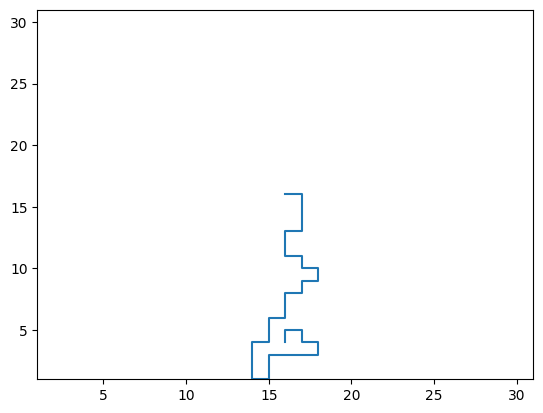

In [ ]:
plt.plot(*zip(*locations))
plt.xlim(1,31)
plt.ylim(1,31)

In [ ]:
calculateEnergy(locations, monomers)

6

# 1M Simulations

In [ ]:
def foldMultipleProteins(M, HProbabilityConst, startingLocation, boundaries):
  energies = []
  lengths = []
  allFoldData = []

  for i in range(M):
    locations, monomers = foldProtein(
        HProbabilityConst,
        startingLocation,
        boundaries
    )
    foldData = {
        'monomers': monomers,
        'locations': locations
    }
    allFoldData.append(foldData)
    L = len(monomers)
    lengths.append(L)
    E = calculateEnergy(locations, monomers)
    energies.append(E)

  return energies, lengths, allFoldData

In [ ]:
energies, lengths, allFoldData = foldMultipleProteins(
    1000000,
    0.7,
    (16,16),
    {'min': 0, 'max': 32}
)

Text(0, 0.5, 'Density')

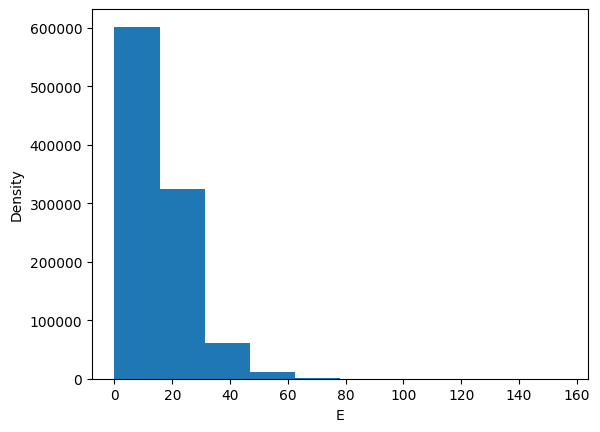

In [ ]:
plt.hist(energies)
plt.xlabel('E')
plt.ylabel('Density')

Text(0, 0.5, 'Density')

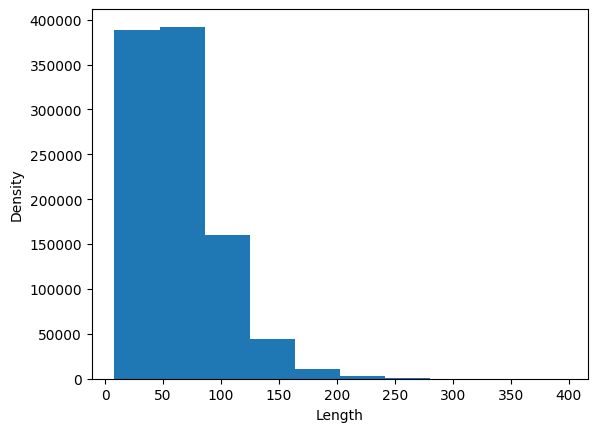

In [ ]:
plt.hist(lengths)
plt.xlabel('Length')
plt.ylabel('Density')

## 3 Sample Simulations

min E:  0
['P', 'H', 'H', 'P', 'H', 'H', 'H', 'P', 'H', 'H', 'H', 'H', 'P', 'H', 'P', 'H', 'H', 'H', 'H', 'P', 'H', 'P']
[(16, 16), (16, 17), (17, 17), (18, 17), (19, 17), (20, 17), (20, 16), (19, 16), (18, 16), (18, 15), (19, 15), (19, 14), (19, 13), (20, 13), (20, 12), (21, 12), (21, 11), (21, 10), (20, 10), (19, 10), (19, 11), (20, 11)]

max E:  59
['H', 'H', 'P', 'H', 'P', 'H', 'P', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'P', 'H', 'H', 'H', 'H', 'P', 'H', 'H', 'H', 'H', 'H', 'P', 'H', 'H', 'P', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'P', 'P', 'H', 'H', 'H', 'P', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'P', 'H', 'H', 'P', 'H', 'H', 'H', 'P', 'H', 'H', 'H', 'P', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'P', 'H', 'P', 'P', 'H', 'P', 'H', 'H', 'H', 'P', 'P', 'H', 'H', 'H', 'H', 'P', 'H', 'H', 'H', 'H', 'H', 'P', 'H', 'P', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'P', 'H', 'H', 'H', 'P', 'H', 'H', 'H', 'H', 'H', 'P', 'H', 'H', 'H', 'H', 'P', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'P', 'H', 

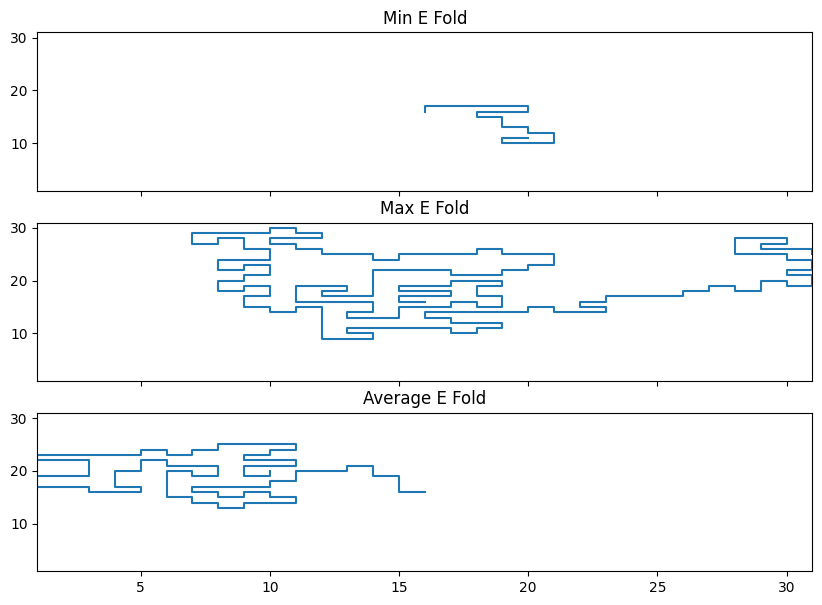

In [ ]:
fig, subPlots = plt.subplots(3,1, sharey=True, sharex=True, figsize=(10,7))

minE = min(energies)
print('min E: ', minE)
minEFoldData = allFoldData[energies.index(minE)]
print(minEFoldData['monomers'])
print(minEFoldData['locations'])

subPlot0 = subPlots.flat[0]
subPlot0.set_title(f"Min E Fold")
subPlot0.plot(*zip(*minEFoldData['locations']))
subPlot0.set_xbound(1,31)
subPlot0.set_ybound(1,31)


maxE = max(energies)
print('\nmax E: ', maxE)
maxEFoldData = allFoldData[energies.index(maxE)]
print(maxEFoldData['monomers'])
print(maxEFoldData['locations'])

subPlot1 = subPlots.flat[1]
subPlot1.set_title(f"Max E Fold")
subPlot1.plot(*zip(*maxEFoldData['locations']))
subPlot1.set_xbound(1,31)
subPlot1.set_ybound(1,31)


# The average E is always achieved?!
averageE = round(0.5*(maxE + minE))
print('\nAverage E: ', averageE)
avrgEFoldData = allFoldData[energies.index(averageE)]
print(avrgEFoldData['monomers'])
print(avrgEFoldData['locations'])
subPlot1 = subPlots.flat[2]
subPlot1.set_title(f"Average E Fold")
subPlot1.plot(*zip(*avrgEFoldData['locations']))
subPlot1.set_xbound(1,31)
subPlot1.set_ybound(1,31)

## E-L Histogram

Highest probability (yellow) is at low energy and small length

Text(0, 0.5, 'L')

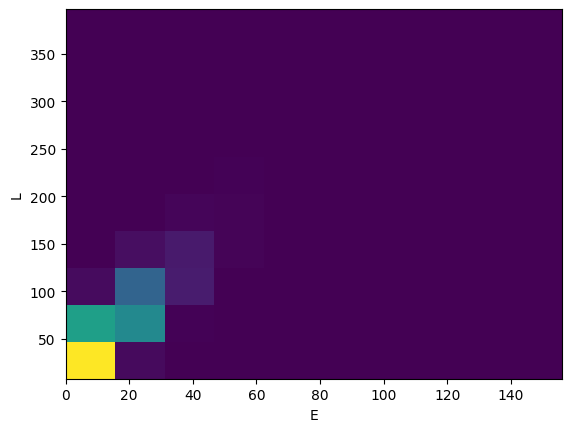

In [ ]:
plt.hist2d(energies, lengths)
plt.xlabel('E')
plt.ylabel('L')